Accuracy : 0.9000
OOB Score: 0.9417

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30


Adjusted Rand Index: 0.6201


c:\Users\me01\miniconda3\envs\ML_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


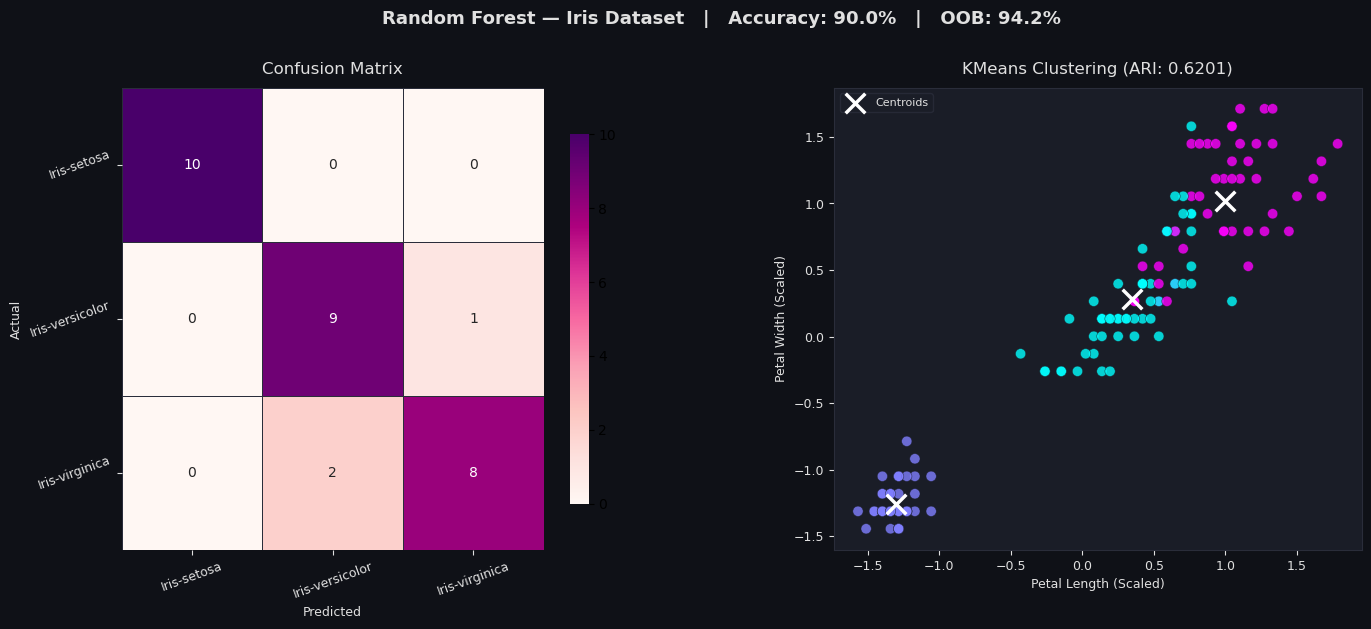

Done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


df = pd.read_csv("Iris.csv")
df.drop(columns=["Id"], inplace=True)

X = df.drop(columns=["Species"])
y = df["Species"]
classes = sorted(y.unique())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
oob    = rf.oob_score_
cm     = confusion_matrix(y_test, y_pred, labels=classes)
report = classification_report(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"OOB Score: {oob:.4f}")
print("\nClassification Report:\n", report)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df['Species_Numeric'] = df['Species'].map(species_map)
ari_score = adjusted_rand_score(df['Species_Numeric'], df['Cluster'])
print(f"\nAdjusted Rand Index: {ari_score:.4f}")


fig = plt.figure(figsize=(16, 6), facecolor="#0f1117")
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ACCENT = ["#7B61FF", "#00D4AA", "#FF6B6B"]
TEXT   = "#E0E0E0"
PANEL  = "#1a1d27"
GRID   = "#2a2d3a"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.title.set_color(TEXT)
    ax.title.set_fontsize(12)
    ax.title.set_fontweight("bold")
    ax.set_title(title, pad=10)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)


ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor=GRID,
            cbar_kws={"shrink": 0.8}, ax=ax1)
ax1.set_xlabel("Predicted", color=TEXT, fontsize=9)
ax1.set_ylabel("Actual", color=TEXT, fontsize=9)
ax1.tick_params(colors=TEXT, rotation=20)
style_ax(ax1, "Confusion Matrix")


ax2 = fig.add_subplot(gs[0, 1])
scatter = ax2.scatter(X_scaled[:, 2], X_scaled[:, 3],
                      c=clusters, cmap="cool", alpha=0.8,
                      edgecolors=PANEL, linewidths=0.4, s=55)
centers = kmeans.cluster_centers_
ax2.scatter(centers[:, 2], centers[:, 3],
            marker="x", s=200, linewidths=2.5,
            color="#FFFFFF", zorder=5, label="Centroids")
ax2.set_xlabel("Petal Length (Scaled)", color=TEXT, fontsize=9)
ax2.set_ylabel("Petal Width (Scaled)",  color=TEXT, fontsize=9)
ax2.legend(facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, fontsize=8)
style_ax(ax2, f"KMeans Clustering (ARI: {ari_score:.4f})")


fig.text(0.5, 1.01, f"Random Forest — Iris Dataset   |   Accuracy: {acc:.1%}   |   OOB: {oob:.1%}",
         ha="center", va="top", color=TEXT, fontsize=13, fontweight="bold")

plt.show()
print("Done.")